In [24]:
import geopandas as gpd
from shapely.geometry import Point
import pandas as pd
from shapely import wkt
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv('data/cleaned_collision_data.csv')

C:\Users\harsh\AppData\Local\Temp\ipykernel_18072\493835407.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/cleaned_collision_data.csv')


In [14]:
df["geometry"] = df.apply(lambda r: Point(r["longitude"], r["latitude"]), axis=1)
gdf_coll = gpd.GeoDataFrame(df, geometry="geometry", crs="EPSG:4326")

In [10]:
bike_df = pd.read_csv("data/New_York_City_Bike_Routes_20251115.csv")
bike_df["geometry"] = bike_df["the_geom"].apply(lambda x: wkt.loads(x) if isinstance(x, str) else None)

bike_gdf = gpd.GeoDataFrame(bike_df, geometry="geometry", crs="EPSG:4326")

bike_gdf.geometry.head()

0    MULTILINESTRING ((-74.19243 40.52174, -74.1951...
1    MULTILINESTRING ((-74.16031 40.58903, -74.1612...
2    MULTILINESTRING ((-74.12632 40.63525, -74.1259...
3    MULTILINESTRING ((-74.00974 40.64567, -74.0103...
4    MULTILINESTRING ((-74.02089 40.62654, -74.0209...
Name: geometry, dtype: geometry

In [11]:
bike_gdf["facilitycl"].unique()


array(['II', 'III', 'I', 'L'], dtype=object)

In [12]:
bike_gdf["bike_type"] = bike_gdf["facilitycl"].map({
    "I": "protected",
    "L": "protected",      
    "II": "unprotected",
    "III": "shared"
}).fillna("unknown")


In [13]:
bike_gdf["bike_type"].value_counts()


bike_type
unprotected    12327
protected      10409
shared          6247
Name: count, dtype: int64

In [15]:
gdf_coll_utm = gdf_coll.to_crs(32618)
gdf_bike_utm = bike_gdf.to_crs(32618)

gdf_bike_utm["buffer"] = gdf_bike_utm.geometry.buffer(10)


In [16]:
joined = gpd.sjoin(
    gdf_coll_utm,
    gdf_bike_utm.set_geometry("buffer")[["buffer", "bike_type"]],
    how="left",
    predicate="intersects"
)

In [17]:
risk = joined.groupby("bike_type").agg(
    cyclists_injured=("number_of_cyclist_injured", "sum"),
    cyclists_killed=("number_of_cyclist_killed", "sum"),
    total_crashes=("collision_id", "count")
).fillna(0)

risk["injury_rate"] = risk["cyclists_injured"] / risk["total_crashes"]
risk["fatality_rate"] = risk["cyclists_killed"] / risk["total_crashes"]

In [18]:
risk

,cyclists_injured,cyclists_killed,total_crashes,injury_rate,fatality_rate
bike_type,,,,,
protected,23645,105,466653,0.050669,0.000225
shared,17092,86,387773,0.044077,0.000222
unprotected,37836,130,697117,0.054275,0.000186


<Figure size 1200x800 with 0 Axes>

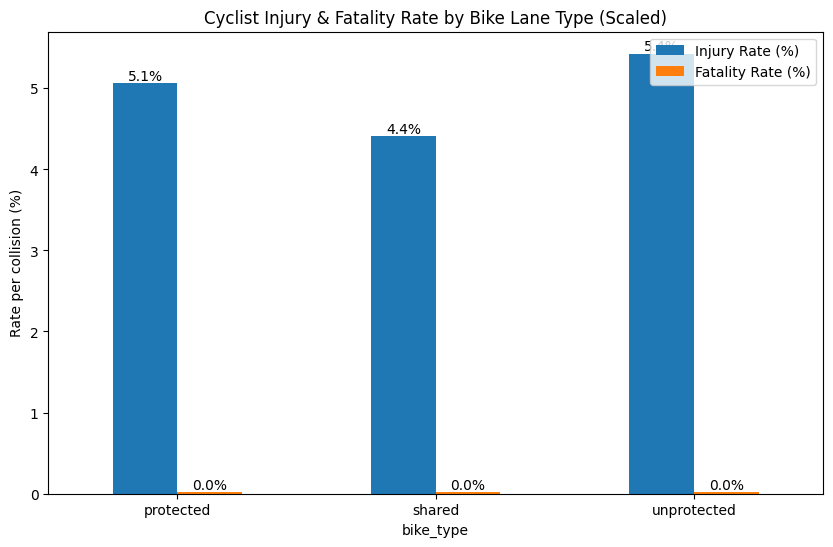

Raw Counts:
             cyclists_injured  cyclists_killed  total_crashes
bike_type                                                    
protected               23645              105         466653
shared                  17092               86         387773
unprotected             37836              130         697117


In [ ]:

plt.figure(figsize=(12, 8))

ax = risk[["injury_rate_scaled", "fatality_rate_scaled"]].plot(kind="bar", figsize=(10,6))
plt.title("Cyclist Injury & Fatality Rate by Bike Lane Type (Scaled)")
plt.ylabel("Rate per collision (%)")
plt.xticks(rotation=0)
plt.legend(["Injury Rate (%)", "Fatality Rate (%)"], loc="upper right")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="edge")

plt.show()

print("Raw Counts:")
print(risk[["cyclists_injured", "cyclists_killed", "total_crashes"]])

In [21]:
joined["borough"].unique()


array(['BROOKLYN', 'BRONX', 'MANHATTAN', 'QUEENS', 'STATEN ISLAND'],
      dtype=object)

In [22]:
risk_borough = joined.groupby(["borough","bike_type"]).agg(
    cyclists_injured=("number_of_cyclist_injured", "sum"),
    cyclists_killed=("number_of_cyclist_killed", "sum"),
    total_crashes=("collision_id", "count")
).fillna(0)

risk_borough["injury_rate"] = risk_borough["cyclists_injured"] / risk_borough["total_crashes"]
risk_borough["fatality_rate"] = risk_borough["cyclists_killed"] / risk_borough["total_crashes"]

risk_borough


cyclists_injured  cyclists_killed  total_crashes  \
borough       bike_type                                                       
BRONX         protected                1332               12          49102   
              shared                   1625               13          50217   
              unprotected              3641               14         112605   
BROOKLYN      protected                6027               28          83155   
              shared                   6203               30         118563   
              unprotected             14557               44         227434   
MANHATTAN     protected               13939               42         285551   
              shared                   5724               12         121859   
              unprotected             13364               39         222908   
QUEENS        protected                2326               23          46747   
              shared                   3214               25          81457   
              unprotected              6026               33         121109   
STATEN ISLAND protected                  21                0           2098   
              shared                    326                6          15677   
              unprotected               248                0          13061   

                           injury_rate  fatality_rate  
borough       bike_type                                
BRONX         protected       0.027127       0.000244  
              shared          0.032360       0.000259  
              unprotected     0.032334       0.000124  
BROOKLYN      protected       0.072479       0.000337  
              shared          0.052318       0.000253  
              unprotected     0.064005       0.000193  
MANHATTAN     protected       0.048814       0.000147  
              shared          0.046972       0.000098  
              unprotected     0.059953       0.000175  
QUEENS        protected       0.049757       0.000492  
              shared          0.039456       0.000307  
              unprotected     0.049757       0.000272  
STATEN ISLAND protected       0.010010       0.000000  
              shared          0.020795       0.000383  
              unprotected     0.018988       0.000000

In [23]:
risk_borough_plot = risk_borough.reset_index()


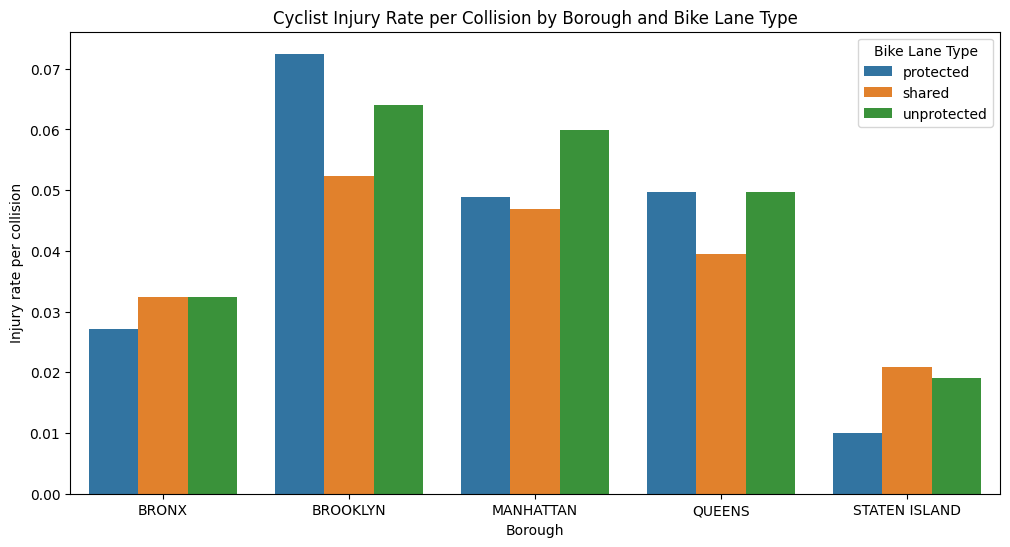

In [25]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=risk_borough_plot,
    x="borough",
    y="injury_rate",
    hue="bike_type"
)
plt.title("Cyclist Injury Rate per Collision by Borough and Bike Lane Type")
plt.ylabel("Injury rate per collision")
plt.xlabel("Borough")
plt.legend(title="Bike Lane Type")
plt.show()